# 로지스틱 회귀 구현 - 과제

---

## 학습 개요

1. **학습 주제**
   - **분류 모델 구현**: 로지스틱 회귀를 통한 이진 분류 모델 구현
   - **손실 함수 이해**: Binary Cross-Entropy(BCE) 손실 함수의 원리와 구현
   - **경사 하강법 적용**: 미니배치 경사 하강법을 활용한 모델 학습 및 최적화

2. **학습 목표**
   - 로지스틱 회귀의 핵심 개념과 흐름을 이해하고, NumPy로 **직접 구현**하여 이진 분류 모델을 **학습·평가**할 수 있다.
    - 시그모이드 함수를 **활성화 함수**로 이해하고, 선형 점수를 확률로 변환하는 과정을 **구현**할 수 있다.
    - Binary Cross-Entropy(BCE) 손실 함수를 **직관적으로 이해**하고 **구현**할 수 있다.
    - BCE 손실 함수의 **그래디언트를 계산**하고 경사 하강법으로 파라미터를 **업데이트**할 수 있다.
    - 미니배치 경사 하강법을 적용하여 모델을 **학습**시키고, **손실 곡선과 정확도**를 통해 수렴 과정을 **해석**할 수 있다.
    - L2 정규화와 조기 종료(Early Stopping) 등의 **학습 기법**을 적용하고 그 효과를 **분석**할 수 있다.

3. **핵심 개념**
   - **시그모이드(Sigmoid) 함수**: 선형 점수 z를 0~1 사이의 확률로 변환하는 활성화 함수로, 이진 분류에서 클래스 1에 속할 확률을 출력한다.
   - **Binary Cross-Entropy(BCE) 손실 함수**: 이진 분류에서 예측 확률과 실제 라벨 간의 차이를 측정하는 손실 함수로, 확률 예측이 틀릴수록 큰 벌점을 부여한다.
   - **그래디언트(Gradient)**: 손실 함수를 파라미터로 미분한 값으로, 파라미터를 어느 방향으로 얼마나 수정해야 손실이 감소하는지 알려준다.
   - **경사 하강법(Gradient Descent)**: 그래디언트를 이용해 손실을 줄이는 방향으로 파라미터를 반복적으로 업데이트하는 최적화 알고리즘이다.
   - **미니배치(Mini-batch)**: 전체 데이터를 작은 배치로 나누어 학습하는 방법으로, 메모리 효율과 수렴 안정성을 개선한다.
   - **L2 정규화(L2 Regularization)**: 파라미터의 크기를 제한하여 과적합을 방지하는 기법이다.

4. **선행 지식**
   - 파이썬 기초 문법(함수, 반복문, 자료구조)
   - NumPy 배열 연산(브로드캐스팅, shape, 벡터화)
   - 선형 회귀의 기본 개념(가설 함수, 손실 함수, 경사 하강법)

5. **실습↔과제 연결**
   - 실습에서 다뤘던 **선형 회귀의 경사 하강법**을 출발점으로 사용합니다.
   - 과제에서는 **조건 변화(약한 변형)** 로 시그모이드 함수와 BCE 손실 함수를 추가하여 분류 문제로 확장하고, **마무리 변형**으로 미니배치 학습, L2 정규화, 조기 종료 등의 학습 기법을 적용합니다.

6. **Further Readings**
   - [Logistic Regression From Scratch in Python NumPy](https://towardsdatascience.com/logistic-regression-from-scratch-in-python-ec66603592e2): 벡터 연산만으로 로지스틱 회귀를 구현하는 과정을 단계별로 설명합니다.
   - [Gradient Descent Cheatsheet & Learning Rate Schedules](https://ml-cheatsheet.readthedocs.io/en/latest/gradient_descent.html): 다양한 학습률 스케줄과 최적화 방법에 대해 정리한 가이드입니다.
   - [Cross-Entropy Loss Explained](https://ml-cheatsheet.readthedocs.io/en/latest/loss_functions.html#cross-entropy): Binary Cross-Entropy의 수학적 배경과 직관적 이해를 제공합니다.

7. **Open-ended Mission**
   - **Multi-Class Softmax Regression 구현**: 소프트맥스 함수와 교차엔트로피 손실을 도입해 Iris의 세 가지 종 모두 분류하기
   - **2D 의사결정 경계(Decision Boundary) 시각화**: 두 개 특성(예: petal_length vs petal_width)만 선택해, 그리드 포인트별 예측 확률을 계산하고 등고선(contour)으로 분류 경계를 그려 모델이 어떻게 클래스를 분리하는지 시각화하기


## 과제 구성

1. **학습 방향**
   - **실습 구성 방식**
     - 각 단계별로 TODO 영역을 채우며 학습자가 직접 구현합니다.

   - **Required Package**
     ```
     python>=3.11
     numpy>=2.0.0
     seaborn>=0.13.2
     matplotlib>=3.8.0
     ```


   - **Step 요약**
     - **Step 1 (30분)**: 데이터셋 불러오기 및 전처리 — Iris 데이터를 이진 분류 문제로 변환하고 train/validation split 수행
     - **Step 2 (40분)**: 로지스틱 회귀 모델 학습 — 시그모이드 함수, BCE 손실, 그래디언트 계산 및 파라미터 업데이트 구현
     - **Step 3 (50분)**: 학습 기법 추가 — 미니배치 학습, L2 정규화, Gradient Accumulation, Early Stopping 구현 및 실험

2. **데이터셋 개요 및 저작권 정보**
   - **데이터셋 명**: Iris Dataset
   - **데이터셋 개요**: 붓꽃 3종(setosa, versicolor, virginica)으로 구성된 고전적인 다중 클래스 분류용 데이터로, 각 샘플은 꽃받침 길이·너비와 꽃잎 길이·너비 4개 특성으로 이루어져 있습니다. 총 150개 샘플로 이루어져 있으며, 데이터 전처리 없이 바로 학습 실습에 활용할 수 있습니다.
   - **사용 목적**: 이진 분류 로지스틱 회귀 모델 학습 및 평가
   - **저작권/출처**: UCI Machine Learning Repository에 공개된 퍼블릭 도메인 데이터로, 원저작권자는 Ronald A. Fisher입니다.
   - **주의사항**: 본 과제에서는 3개 클래스 중 virginica를 1로, 나머지를 0으로 변환하여 이진 분류 문제로 단순화합니다.

3. **문제 설명**
   - **문제 개요**: 이 과제는 **로지스틱 회귀를 이용한 이진 분류**의 기초를 다지기 위해 설계되었습니다. 학습자는 **시그모이드 함수, BCE 손실, 경사 하강법, 미니배치 학습**을 코드로 확인하고, 최종적으로 **모델을 학습·평가·최적화·해석**할 수 있어야 합니다.
   - **요구사항 요약**
        - **데이터 준비**: Iris 데이터를 이진 분류 문제로 변환하고 train/validation split 수행
        - **모델 구현**: 시그모이드 함수, BCE 손실, 그래디언트 계산 및 파라미터 업데이트 구현
        - **학습 기법**: 미니배치 학습, L2 정규화, Gradient Accumulation, Early Stopping 구현
        - **평가 및 해석**: 정확도 계산 및 손실 곡선 시각화를 통한 수렴 과정 분석

4. **학습 문제: Step–TODO 구체 설명**
   - **Step 1 — 데이터셋 불러오기 및 전처리**
      - **TODO 1**: 데이터 섞기 및 train/validation split *(연결 핵심개념: 데이터 전처리 / 일반화 성능)*
      - **TODO 2**: 데이터 표준화 *(연결 핵심개념: 특성 스케일링 / 학습 안정성)*
      - **1줄 요약**: 데이터를 학습에 적합한 형태로 준비하고 일반화 성능을 평가할 수 있도록 분할한다.
   - **Step 2 — 로지스틱 회귀 모델 학습**
      - **TODO 3**: 예측(Forward) -> 손실 계산(Loss) -> 기울기 산출(Backward) -> 파라미터 업데이트로 이어지는 기본 로지스틱 회귀 학습 루프를 구현 (*연결 핵심개념: 시그모이드 함수, 확률 예측, BCE 손실 함수, 그래디언트  경사 하강법*)
      - **1줄 요약**: 로지스틱 회귀의 핵심 요소를 구현하고 모델을 학습시킨다.
   - **Step 3 — 학습 기법 추가**
     - **TODO 4**: 학습 효율과 일반화 성능을 높이기 위해 미니배치 처리, L2 규제, 그라디언트 누적, 조기 종료(Early Stopping) 기능을 추가 *(연결 핵심개념: 미니배치 / 메모리 효율)*
     - **TODO 5**: 다양한 하이퍼파라미터(학습률, 규제 강도 등) 조합으로 실험을 수행하고, Loss 곡선을 시각화하여 모델 성능을 비교 *(연결 핵심개념: 모델 평가 / 수렴 확인)*
     - **1줄 요약**: 실무에서 사용되는 학습 기법을 추가하여 모델 성능과 효율을 개선한다.

5. **주의사항**
   - 학습이 발산하면 학습률(lr)을 줄이고, batch size/epoch을 조정하세요.
   - 구현 중에는 각 배열의 shape을 출력해 확인하면 디버깅 시간이 크게 줄어듭니다.

## Install & Import

In [1]:
# 공통 실습 환경 설치 (최초 1회 실행)
!pip install -q \
    "numpy>=2.0.0" \
    "matplotlib>=3.8.0" \
    "seaborn>=0.13.2"


In [2]:
from typing import Tuple, List, Optional
from itertools import product

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme()

## Concept Check: 활성화 함수와 손실 함수

### 1. 로지스틱 회귀란?

앞선 실습에서는 선형 회귀를 통해 **연속적인 값을 예측**하는 회귀 과제를 수행했습니다. 그렇다면 분류 과제에서는 어떤 알고리즘이 가장 기초적일까요? 바로 **로지스틱 회귀**입니다. 이름에 회귀가 있지만 실제로는 **분류를 수행하는 모델**입니다.

로지스틱 회귀는 입력 벡터 $\mathbf{x}$를 선형 결합한 점수 $z = \mathbf{x}^\top \mathbf{w} + b$를 시그모이드 함수를 통해 확률로 매핑하여 이진 분류를 수행하는 확률적 선형 모델입니다.

### 2. 시그모이드 함수 — 점수를 확률로 변환하는 활성화 함수

선형 회귀의 출력값은 $(-\infty, +\infty)$ 범위의 실수입니다. 하지만 분류 문제에서는 **0과 1 사이의 확률**이 필요합니다. 이때 사용하는 것이 **시그모이드(Sigmoid) 함수**입니다.

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

시그모이드 함수는 **활성화 함수(Activation Function)**로, 선형 점수 $z$를 0~1 사이의 확률로 변환합니다.

- **$z=0$일 때**: $\sigma(0) = 0.5$ (중립적인 예측)
- **$z > 0$일 때**: $\sigma(z) > 0.5$ (클래스 1에 가까움)
- **$z < 0$일 때**: $\sigma(z) < 0.5$ (클래스 0에 가까움)

**임계값(Threshold)**: 일반적으로 $\sigma(z) \geq 0.5$이면 클래스 1로, $\sigma(z) < 0.5$이면 클래스 0으로 분류합니다. 이 기준점 0.5를 **결정 경계(Decision Boundary)**라고 합니다.

아래 코드는 시그모이드 함수의 형태를 시각화합니다.


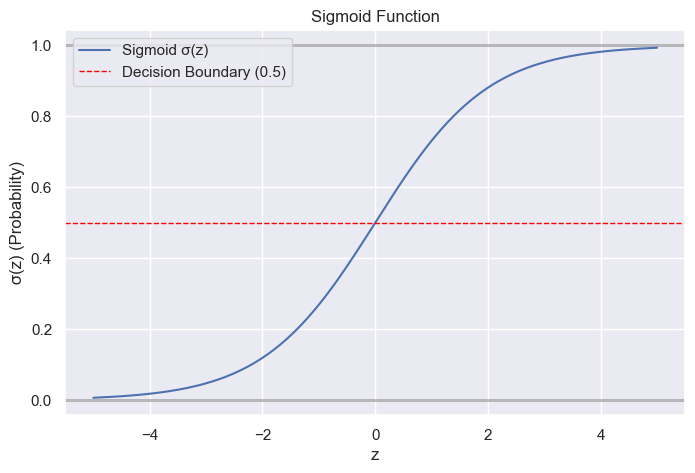

In [3]:
def sigmoid(z: np.ndarray) -> np.ndarray:
    """시그모이드 함수: 선형 점수를 0~1 확률로 변환"""
    # 안정성 향상: 큰 음수/양수에서 overflow 방지
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

z = np.linspace(-5, 5, 200)
p = sigmoid(z)

plt.figure(figsize=(8, 5))
sns.lineplot(x=z, y=p, label='Sigmoid σ(z)')
plt.title("Sigmoid Function")
plt.xlabel("z")
plt.ylabel("σ(z) (Probability)")
# 0.5 기준선: 분류 결정 경계를 나타냄
plt.axhline(0.5, color='red', linestyle='--', linewidth=1, label='Decision Boundary (0.5)')
# 0과 1 경계: 확률의 최소/최대값
plt.axhline(0.0, color='k', linestyle='-', linewidth=2, alpha=0.3)
plt.axhline(1.0, color='k', linestyle='-', linewidth=2, alpha=0.3)
plt.legend()
plt.show()

### 3. 손실 함수 — Binary Cross-Entropy(BCE)

모델을 학습시키려면 **현재 파라미터가 얼마나 좋은지**를 평가하는 기준이 필요합니다. 이것이 바로 **손실 함수(Loss Function)** 입니다.

회귀 문제에서는 평균제곱오차(MSE)를 사용했지만, 분류 문제에서는 **Binary Cross-Entropy(BCE)** 를 사용합니다.

$$
L(\mathbf{w}, b) = -\frac{1}{m} \sum_{i=1}^m \left[ y_i \log(\hat{p}_i) + (1 - y_i)\log(1 - \hat{p}_i) \right]
$$

여기서 $\hat{p}_i = \sigma(\mathbf{x}_i^\top \mathbf{w} + b)$는 모델이 예측한 확률이고, $y_i \in \{0, 1\}$은 실제 라벨입니다.

#### BCE의 직관적 이해

BCE는 **확률 예측이 틀릴수록 큰 벌점을 주는 기준**입니다. 두 경우로 나누어 살펴봅시다.

- **$y_i = 1$일 때** (실제 클래스가 1):
  - 손실 = $-\log(\hat{p}_i)$
  - $\hat{p}_i$가 1에 가까우면 손실이 0에 가까워집니다. (정확한 예측)
  - $\hat{p}_i$가 0에 가까우면 손실이 무한대로 발산합니다. (매우 잘못된 예측)

- **$y_i = 0$일 때** (실제 클래스가 0):
  - 손실 = $-\log(1 - \hat{p}_i)$
  - $\hat{p}_i$가 0에 가까우면 손실이 0에 가까워집니다. (정확한 예측)
  - $\hat{p}_i$가 1에 가까우면 손실이 무한대로 발산합니다. (매우 잘못된 예측)

**왜 정확도가 아닌 손실을 사용할까요?**

정확도는 0/1로만 판단하지만(맞다/틀리다), BCE는 **확률의 확신도**까지 고려합니다. 예를 들어, 실제 라벨이 1일 때 모델이 0.51과 0.99를 예측한 경우, 정확도는 둘 다 "맞음"으로 처리하지만 BCE는 0.99에 훨씬 낮은 손실을 부여하여 더 확신 있는 예측을 유도합니다.

### 4. 그래디언트 계산 — 파라미터를 어떻게 업데이트할까?

경사 하강법을 적용하려면 손실 함수를 파라미터로 미분한 **그래디언트(Gradient)**가 필요합니다.

로지스틱 회귀의 그래디언트는 다음과 같이 계산됩니다.

$$
\nabla_\mathbf{w} = \frac{1}{m} \mathbf{X}^\top (\hat{\mathbf{p}} - \mathbf{y}), \quad
\nabla_b = \frac{1}{m} \sum_{i=1}^m (\hat{p}_i - y_i)
$$

여기서:
- $\mathbf{X}$: 입력 데이터 행렬 (shape: [m, n])
- $\hat{\mathbf{p}}$: 예측 확률 벡터 (shape: [m])
- $\mathbf{y}$: 실제 라벨 벡터 (shape: [m])

### 5. 모델 평가 — 정확도(Accuracy)

BCE 손실 함수는 학습에는 유용하지만, **사람이 직관적으로 이해하기 어렵습니다**. 따라서 모델 성능을 평가할 때는 **정확도(Accuracy)** 를 함께 사용합니다.

$$
\text{Accuracy} = \frac{\text{올바르게 예측한 샘플 수}}{\text{전체 샘플 수}}
$$

정확도는 간단하지만, 클래스 불균형 문제 등에서 취약할 수 있습니다. 추후 분류 모델의 다양한 평가 지표를 배우게 됩니다.


## Step 1: 데이터셋 불러오기 및 전처리

### Concept Check

**데이터 전처리의 중요성**

모델을 학습시키기 전에 데이터를 적절히 준비하는 것이 중요합니다. 이번 Step에서는 다음을 수행합니다.

1. **이진 분류 문제로 변환**: Iris 데이터는 3개 클래스를 가지지만, 로지스틱 회귀는 이진 분류 모델이므로 virginica를 1로, 나머지를 0으로 변환합니다.
2. **데이터 섞기**: 데이터가 클래스별로 정렬되어 있으면 학습이 편향될 수 있으므로 무작위로 섞습니다.
3. **Train/Validation Split**: 전체 데이터의 80%를 학습용, 20%를 검증용으로 나누어 일반화 성능을 평가합니다.
4. **표준화(Standardization)**: 각 특성의 평균을 0, 표준편차를 1로 조정하여 학습을 안정화하고 수렴 속도를 개선합니다.


In [4]:
# 오늘 사용할 붓꽃 데이터입니다
df = sns.load_dataset("iris")

# Feature만 포함된 X와 라벨값인 y를 저장해주세요
# 실제 데이터는 3개의 클래스로 되어 있으나,
# 오늘은 이진분류 과제를 수행할 것이기 때문에 virginica를 1, 나머지 클래스를 0으로 변환하여 사용합니다.
X = df.drop("species", axis=1).values
y = df.species.values
y = np.where(y == "virginica", 1, 0)

### TODO 1: 데이터 섞기 및 Train/Validation 분할
**요구사항**   
1. Iris 데이터는 타겟값(`species`) 기준으로 정렬되어 있으므로, 편향된 학습을 막기 위해 **데이터의 순서를 무작위로 섞어주세요.** (Numpy의 `permutation` 활용)
2. 섞인 데이터를 **학습(Train) 80%**, **검증(Validation) 20%** 비율로 분할하세요.
3. 분할된 결과는 `X_train`, `y_train`, `X_valid`, `y_valid` 변수에 할당합니다.

**힌트**
- [`numpy.random.permutation`](https://numpy.org/doc/2.2/reference/random/generated/numpy.random.permutation.html)을 활용해보세요

In [5]:
n: int = X.shape[0]
idx: List[int] = np.random.permutation(n)

train_ratio: float = 0.8
cut: int = int(n * train_ratio)

train_index, validation_index = idx[:cut], idx[cut:]

X_train, X_valid = X[train_index], X[validation_index]
y_train, y_valid = y[train_index], y[validation_index]

### TODO 2: 데이터 표준화 (Standardization)

**요구사항**
1. 데이터를 평균 0, 표준편차 1이 되도록 **표준화**하세요.
2. **Data Leakage(데이터 누수) 방지**를 위해 반드시 다음 규칙을 따라야 합니다:
    - `mu`(평균)와 `sigma`(표준편차)는 오직 **`X_train` 데이터만을 기준**으로 계산해야 합니다.
    - 계산된 `mu`, `sigma`를 사용하여 `X_train`과 `X_valid`를 모두 변환하세요.
3. `sigma`가 0일 경우 나눗셈 에러를 방지하기 위해 1.0으로 대체하는 안전장치를 추가하세요.

**참고**: 데이터 누수(Data Leakage)는 검증/테스트 데이터의 정보가 학습 과정에 섞여 성능이 과대평가되는 문제입니다.
예를 들어 `X_train`과 `X_valid`를 합쳐 평균/표준편차를 구하면, 검증 데이터 정보가 학습 단계에 유입되어 실제보다 높은 성능이 나올 수 있습니다.


In [6]:
mu = X_train.mean(axis=0)
sigma = X_train.std(axis=0, ddof=0)
sigma[sigma == 0.0] = 1.0

X_train = (X_train - mu) / sigma
X_valid = (X_valid - mu) / sigma

print(f"Train 데이터 shape: X={X_train.shape}, y={y_train.shape}")
print(f"Valid 데이터 shape: X={X_valid.shape}, y={y_valid.shape}")

Train 데이터 shape: X=(120, 4), y=(120,)
Valid 데이터 shape: X=(30, 4), y=(30,)


## Step 2: 로지스틱 회귀 모델 학습

### Concept Check

**로지스틱 회귀 학습 과정**

로지스틱 회귀 모델을 학습시키는 과정은 다음과 같습니다.

1. **예측 확률 계산**: 현재 파라미터 $\mathbf{w}, b$를 사용하여 $\hat{p} = \sigma(\mathbf{X}\mathbf{w} + b)$를 계산합니다.
2. **손실 계산**: BCE 손실 함수로 예측과 실제 라벨의 차이를 측정합니다.
3. **그래디언트 계산**: 손실 함수를 파라미터로 미분하여 업데이트 방향을 결정합니다.
4. **파라미터 업데이트**: 그래디언트를 이용해 $\mathbf{w}, b$를 업데이트합니다.

이 과정을 여러 번 반복하면 손실이 점차 감소하고 모델이 학습됩니다.


### TODO 3: 로지스틱 회귀 모델 구현 및 학습

**요구사항**
로지스틱 회귀의 핵심인 **예측 확률 계산**과 **학습(Training) 과정**을 구현하세요.

1. **`predict_proba` 함수**:
   - 입력 데이터($X$), 가중치($W$), 편향($b$)을 받아 시그모이드 함수를 통과한 예측 확률($p$)을 반환합니다.

2. **`train_logistic_regression` 함수**:
    주어진 Epoch만큼 반복하며 모델을 학습시킵니다.
   1. **Forward**: `predict_proba`를 사용하여 예측값($p$)을 계산합니다.
   2. **Loss**: Binary Cross-Entropy 공식을 사용하여 손실(Loss)을 계산하고 `losses` 리스트에 저장합니다. (Log 계산 시 `eps`를 더해 수치 안정성을 확보하세요.)
   3. **Backward**: 가중치($W$)와 편향($b$)에 대한 기울기(Gradient)를 계산합니다.
   4. **Update**: 학습률(`lr`)을 사용하여 파라미터를 업데이트합니다.

In [7]:
def predict_proba(
    W: np.ndarray,
    b: float,
    X: np.ndarray
  ) -> np.ndarray:
    """학습데이터와 매개변수가 주어졌을 때 확률값을 예측하는 함수"""
    return sigmoid(X @ W + b)


def train_logistic_regression(
    X: np.ndarray,
    y: np.ndarray,
    lr: float = 0.1,
    epochs: int = 300,
    eps: float = 1e-12
  ) -> Tuple[np.ndarray, np.ndarray, List[float]]:
    """로지스틱 회귀 모델 학습

    Args:
        X: 입력 데이터 (shape: [m, n])
        y: 라벨 (shape: [m])
        lr: 학습률
        epochs: 전체 반복 횟수
        eps: 수치 안정성을 위한 작은 값

    Returns:
        W: 학습된 가중치
        b: 학습된 편향
        losses: 각 epoch의 손실 값
    """
    # 매개변수 초기화
    m, n = X.shape
    W = np.zeros(n)
    b = 0.0
    losses = []

    for _ in range(epochs):
        # 1. Forward: 예측값 계산
        p = predict_proba(W, b, X)

        # 2. Loss: Binary Cross-Entropy 손실 계산
        loss = -np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))
        losses.append(loss)

        # 3. Backward: 그래디언트 계산
        diff = (p - y) / m
        gW = X.T @ diff
        gb = np.sum(diff)

        # 4. Update: 파라미터 업데이트
        W -= lr * gW
        b -= lr * gb

    return W, b, losses

### Test (Checkpoint)

구현한 함수를 사용하여 모델을 학습시키고, 정확도와 손실 곡선을 확인합니다.


Train Accuracy: 0.9250
Valid Accuracy: 0.9333


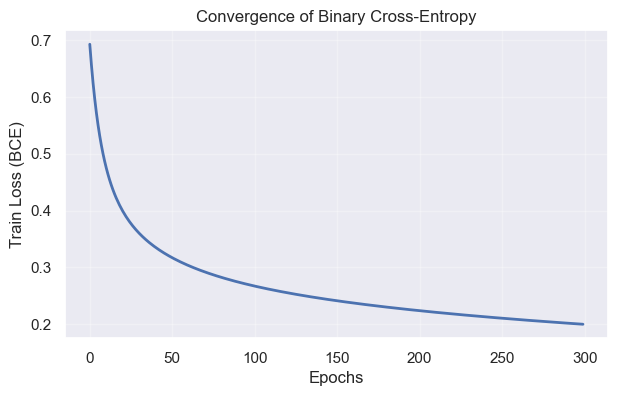

In [8]:
# 위에서 짠 코드는 잘 작동할까요? 한 번 검증해봅시다!
W, b, losses = train_logistic_regression(X_train, y_train, lr=0.1, epochs=300)

def accuracy(W, b, X, y):
    """정확도 계산: 예측 확률이 0.5 이상이면 클래스 1로 분류"""
    prediction = predict_proba(W, b, X) > 0.5
    return (prediction == y).mean()

print(f"Train Accuracy: {accuracy(W, b, X_train, y_train):.4f}")
print(f"Valid Accuracy: {accuracy(W, b, X_valid,  y_valid):.4f}")

plt.figure(figsize=(7,4))
# 손실 곡선: 감소 추세는 학습이 잘 진행됨을 의미하고, 수렴은 최적점에 도달했음을 나타냄
plt.plot(losses, linewidth=2)
plt.xlabel("Epochs")
plt.ylabel("Train Loss (BCE)")
plt.title("Convergence of Binary Cross-Entropy")
plt.grid(alpha=0.3)
plt.show()

## Step 3: 학습 기법 추가

### Concept Check

**실무에서 사용되는 학습 기법들**

지금까지 구현한 로지스틱 회귀는 전체 데이터에 대해 한 번에 그래디언트를 계산했습니다(Batch Gradient Descent). 하지만 실무에서는 다음과 같은 기법들을 추가로 사용합니다.

1. **Mini-Batch Training**: 전체 데이터를 작은 배치로 나누어 학습합니다. 메모리 효율이 좋고, 학습이 더 안정적입니다.

2. **Gradient Accumulation**: 메모리 제약으로 큰 배치를 사용할 수 없을 때, 작은 배치의 그래디언트를 누적하여 큰 배치 효과를 냅니다.

3. **Early Stopping**: 손실이 개선되지 않으면 학습을 조기에 종료하여 시간을 절약하고 과적합을 방지합니다.

4. **L2 Regularization**: 파라미터의 크기를 제한하여 과적합을 방지합니다. 손실 함수에 다음 항을 추가합니다.

$$
L_{\text{total}} = L_{\text{BCE}} + \frac{\lambda}{2} \|\mathbf{w}\|_2^2
$$

이에 따라 그래디언트도 변경됩니다.

$$
\nabla_{\mathbf{w}} = \frac{1}{m} \mathbf{X}^\top (\hat{\mathbf{p}} - \mathbf{y}) + \lambda \mathbf{w}
$$

$$
\nabla_b = \frac{1}{m} \sum_{i=1}^m (\hat{p}_i - y_i)
$$


### TODO 4: 심화 로지스틱 회귀 모델 구현 (Advanced Features)

기본 로지스틱 회귀에 학습 성능과 안정성을 높이기 위한 4가지 기능을 추가하여 `train_logistic_regression_improve` 함수를 완성하세요.

**요구사항**

1. 미니배치 데이터 섞기 (Shuffling)
    * 매 Epoch 시작마다 데이터를 무작위로 섞어 학습의 편향을 방지하세요.
    * 섞인 데이터를 `batch_size` 크기만큼 잘라서 학습에 사용합니다.
    * TODO 1에서 사용한 `numpy.random.permutation`을 활용합니다.

2. L2 정규화 (Regularization) 적용
    * 예측 및 그래디언트 계산 및 파라미터 업데이트를 수행하세요.
      * 이 때, 가중치 업데이트 시 위에서 배운 과적합 방지를 위해 **L2 규제**를 적용하세요.   
      * $Gradient = \nabla W + \lambda W$ (여기서 $\lambda$는 `l2` 파라미터)


3. 그라디언트 누적 (Gradient Accumulation)
    * 배치마다 즉시 업데이트하지 않고, 그라디언트를 `gW_acc`, `gb_acc`에 누적하세요.
    * `accumulate_n`번 누적되었을 때 평균 그라디언트로 파라미터를 업데이트하고, 누적 변수를 초기화합니다.
    * 루프가 끝난 후 남은 누적분이 있다면 추가로 업데이트를 수행하세요.

4. Epoch 손실 계산
    * 한 Epoch의 학습이 끝날 때마다 전체 데이터에 대한 Loss를 계산하여 기록하세요.
    * 이때 L2 페널티 항($\frac{1}{2} \lambda \sum W^2$)도 Loss에 포함되어야 합니다.
  
5. 조기 종료 (Early Stopping)
    * 학습 중 `best_loss`를 기록합니다.
    * 현재 Epoch의 Loss가 `best_loss`보다 개선되지 않는 상황이 `patience` 횟수만큼 지속되면 학습을 중단(`break`)하세요.
    * 학습 종료 시점에는 가장 성능이 좋았던 파라미터(`best_W`, `best_b`)로 복원해야 합니다.

미니배치 학습, L2 정규화, Gradient Accumulation, Early Stopping을 모두 포함한 학습 함수를 구현하세요.


In [9]:
def train_logistic_regression_improve(
    X: np.ndarray,
    y: np.ndarray,
    lr: float = 0.1,
    epochs: int = 300,
    eps: float = 1e-12,
    # 새롭게 추가된 arguments
    batch_size: Optional[int] = None,   # None 이면 full batch
    l2: float = 0.0,                    # L2 강도 (0.0 이면 off)
    accumulate_n: int = 1,              # 그라디언트 누적 스텝
    patience: int = 0                   # early stopping 윈도우, 0 이면 off
) -> Tuple[np.ndarray, float, List[float]]:
    """개선된 로지스틱 회귀 학습 함수

    Args:
        X: 입력 데이터
        y: 라벨
        lr: 학습률
        epochs: 전체 반복 횟수
        eps: 수치 안정성을 위한 작은 값
        batch_size: 미니배치 크기 (None이면 전체 데이터)
        l2: L2 정규화 강도
        accumulate_n: 그래디언트 누적 스텝 수
        patience: Early Stopping을 위한 patience

    Returns:
        W: 학습된 가중치
        b: 학습된 편향
        losses: 각 epoch의 손실 값
    """
    m, n = X.shape
    W = np.zeros(n)
    b = 0.0
    losses: List[float] = []

    # Early Stopping 변수
    best_loss = np.inf
    best_W, best_b = W.copy(), b
    no_improve = 0

    # 배치 사이즈 설정 (None일 경우 전체 데이터 사용)
    if batch_size is None or batch_size > m:
        batch_size = m

    for ep in range(epochs):
        # 1. 데이터 섞기
        idx = np.random.permutation(m)
        Xs, ys = X[idx], y[idx]

        # 누적 버퍼 초기화
        gW_acc = np.zeros_like(W)
        gb_acc = 0.0
        cnt = 0

        # 미니배치 루프
        for start in range(0, m, batch_size):
            xb = Xs[start:start+batch_size]
            yb = ys[start:start+batch_size]

            # 2. L2 정규화가 포함된 그래디언트 계산
            # 예측 및 그래디언트 계산
            p = predict_proba(W, b, xb)
            diff = (p - yb) / xb.shape[0]
            gW = xb.T @ diff + (l2 * W)
            gb = diff.sum()

            # 3. 그라디언트 누적
            gW_acc += gW
            gb_acc += gb
            cnt += 1

            # 2(계속). 누적 횟수 도달 시 업데이트 및 초기화
            if cnt == accumulate_n:
                W -= lr * (gW_acc / cnt)
                b -= lr * (gb_acc / cnt)
                gW_acc[:] = 0
                gb_acc = 0.0
                cnt = 0

        # 2(계속). 루프 종료 후 남은 누적분 업데이트
        if cnt > 0:
            W -= lr * (gW_acc / cnt)
            b -= lr * (gb_acc / cnt)

        # 4. Epoch 종료 후 전체 Loss 계산 (Logging용)
        p_all = predict_proba(W, b, X)
        epoch_loss = -np.mean(y * np.log(p_all + eps) + (1 - y) * np.log(1 - p_all + eps))
        if l2 > 0:
            epoch_loss += 0.5 * l2 * np.sum(W**2)
        losses.append(epoch_loss)

        # 5. 조기 종료
        if patience > 0:
            # 5. 조기 종료
            # Early stopping 로직을 조건문(if)를 통해 완성해주세요
            if epoch_loss < best_loss - eps:
                best_loss = epoch_loss
                best_W, best_b = W.copy(), b
                no_improve = 0
            else:
                no_improve += 1
                if no_improve >= patience:
                    print(f"Early stopping at epoch {ep+1}")
                    W, b = best_W, best_b  # 최적의 가중치 복원
                    break

    return W, b, losses

### Test (Checkpoint)

개선된 학습 함수를 사용하여 모델을 학습시키고 결과를 확인합니다.


Train Accuracy: 0.9500
Valid Accuracy: 0.9667


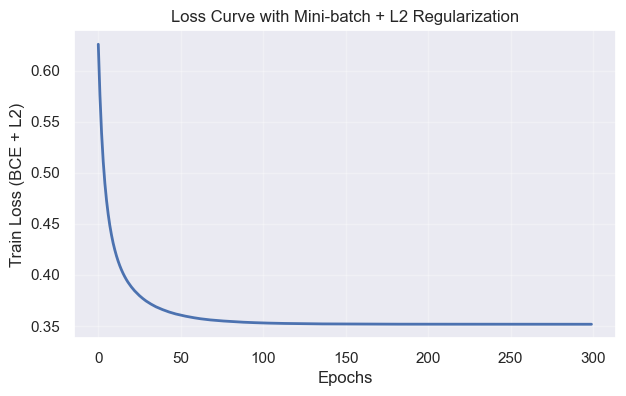

In [10]:
# 개선된 학습 함수로 모델 학습
W, b, losses = train_logistic_regression_improve(
    X_train, y_train,
    lr=0.1,
    epochs=300,
    batch_size=32,
    l2=0.1,
    accumulate_n=2,
    patience=20
)

print(f"Train Accuracy: {accuracy(W, b, X_train, y_train):.4f}")
print(f"Valid Accuracy: {accuracy(W, b, X_valid,  y_valid):.4f}")

plt.figure(figsize=(7,4))
# 손실 곡선: 미니배치 학습으로 인해 약간의 진동이 있을 수 있지만, 전체적으로 감소 추세를 보임
plt.plot(losses, linewidth=2)
plt.xlabel("Epochs")
plt.ylabel("Train Loss (BCE + L2)")
plt.title("Loss Curve with Mini-batch + L2 Regularization")
plt.grid(alpha=0.3)
plt.show()

### TODO 5: 하이퍼파라미터 튜닝 및 결과 시각화

**요구사항**
다양한 하이퍼파라미터 조합이 모델의 학습 성능(Loss)과 검증 정확도(Accuracy)에 어떤 영향을 미치는지 실험합니다.

1.  **실험 조합 설정**:
    * `lrs` (학습률): `0.1`, `0.01`
    * `l2s` (L2 규제 강도): `0.0` (규제 없음), `0.1`
    * `accs` (그래디언트 누적 스텝): `1` (기본), `2`
    * `itertools.product`를 사용하여 위 3가지 변수의 모든 가능한 조합을 만드세요.

2.  **실험 루프 및 시각화**:
    * 각 조합에 대해 `train_logistic_regression_improve` 함수를 실행하여 모델을 학습시킵니다. (Epochs: 300, Patience: 0, Batch Size: 32)
    * 학습된 모델(`W`, `b`)을 사용하여 Validation 데이터에 대한 **정확도(Accuracy)**를 계산합니다.
    * Epoch별 **Loss 변화 곡선**을 그래프(`plt.plot`)로 그립니다.
    * 범례(Legend)에는 사용된 하이퍼파라미터와 최종 Validation Accuracy를 표시하세요.

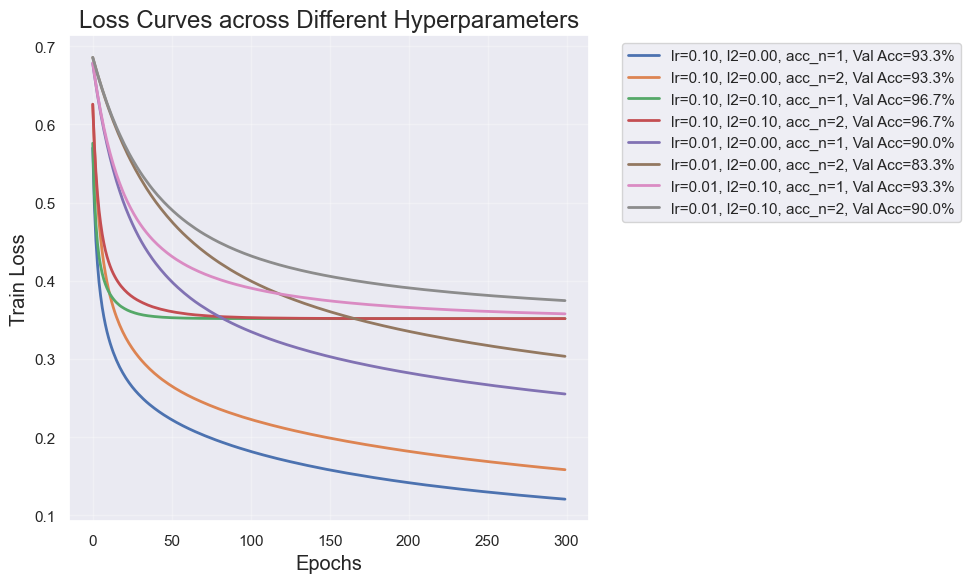

In [11]:
# 1. 실험 조합 설정 (학습률, L2, 누적 스텝)
lrs = [0.1, 0.01]
l2s = [0.0, 0.1]
accs = [1, 2]
experiments = list(product(lrs, l2s, accs))

# 2. 실험 루프 및 시각화
plt.figure(figsize=(10, 6))
for lr, l2, acc_n in experiments:
    # 모델 학습 수행
    W, b, losses = train_logistic_regression_improve(
        X_train, y_train,
        lr=lr,
        l2=l2,
        accumulate_n=acc_n,
        epochs=300,
        patience=0,
        batch_size=32
    )
    
    # Validation data에 대한 정확도 계산 및 시각화
    acc = accuracy(W, b, X_valid, y_valid)
    
    label = f"lr={lr:.2f}, l2={l2:.2f}, acc_n={acc_n}, Val Acc={acc*100:3.1f}%"
    plt.plot(losses, label=label, linewidth=2)

plt.xlabel("Epochs", size="large")
plt.ylabel("Train Loss", size="large")
plt.title("Loss Curves across Different Hyperparameters", size="x-large")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 학생용 자가 체크리스트

- [ ] **Data Leakage 방지**: 검증 데이터(Validation)를 표준화할 때, 왜 **학습 데이터(Train)의 평균과 표준편차**를 사용해야 하는지 명확히 이해했나요?
- [ ] **로지스틱 회귀의 흐름**: `X @ W + b` (선형 결합) $\rightarrow$ `Sigmoid` (확률 변환) $\rightarrow$ `Cross-Entropy` (손실 계산) $\rightarrow$ `Gradient Descent` (파라미터 업데이트)로 이어지는 전체 학습 사이클을 설명할 수 있나요?
- [ ] **미니배치와 셔플링**: 전체 데이터를 한 번에 학습하는 것과 비교하여, **데이터를 섞고(Shuffling) 미니배치 단위로 학습**하는 것이 학습 효율과 안정성에 어떤 영향을 주는지 알고 있나요?
- [ ] **과적합(Overfitting) 제어**: 모델이 학습 데이터에만 너무 익숙해지는 것을 막기 위해 사용한 **L2 규제(Regularization)**와 **조기 종료(Early Stopping)**의 원리를 이해했나요?
- [ ] **결과 해석 능력**: 학습률(Learning Rate)이나 그라디언트 누적(Accumulation) 등 **하이퍼파라미터 변화에 따른 Loss 곡선의 차이**를 보고 모델의 상태를 진단할 수 있나요?

### **Content License Agreement**

<font color='red'><b>**WARNING**</b></font> : 본 자료는 삼성청년SW·AI아카데미의 컨텐츠 자산으로, 보안서약서에 의거하여 어떠한 사유로도 임의로 복사, 촬영, 녹음, 복제, 보관, 전송하거나 허가 받지 않은 저장매체를 이용한 보관, 제3자에게 누설, 공개 또는 사용하는 등의 무단 사용 및 불법 배포 시 법적 조치를 받을 수 있습니다.